MSE: 24928823594.88
R²: 0.84
   Фактическая цена  Предсказанная цена
0            150000      -253981.623028
1            387545       161689.847727
2            301821        92417.402211
3            281093         9744.802292
4            867164       966062.806115
5            537007       563656.160982


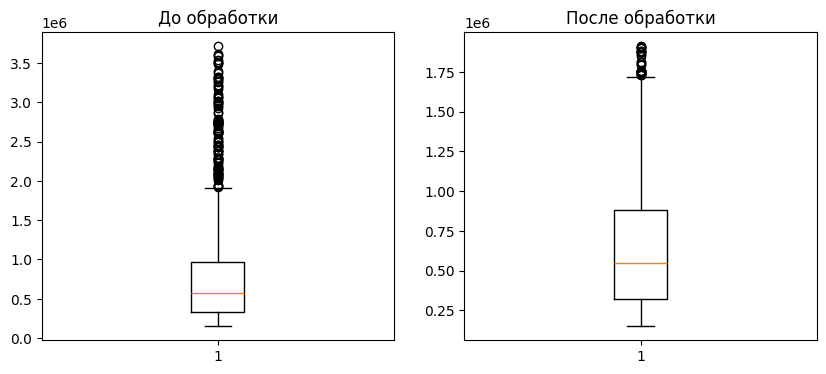

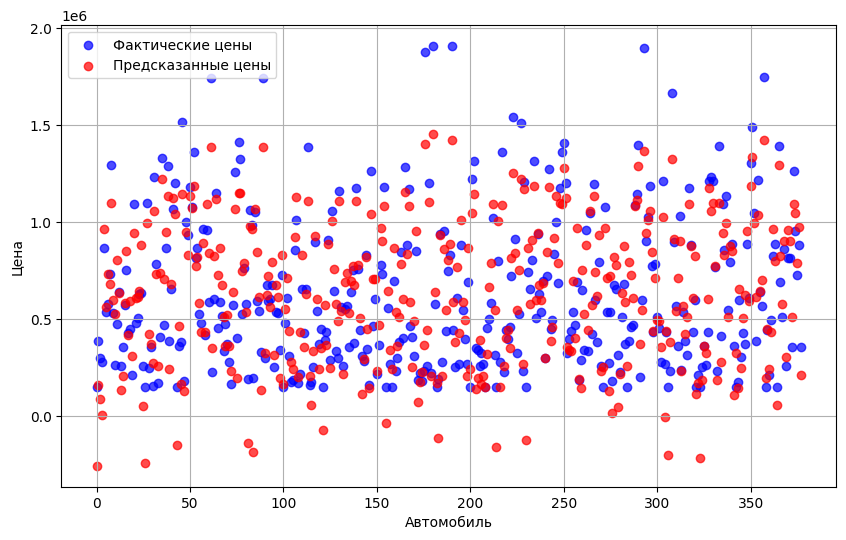

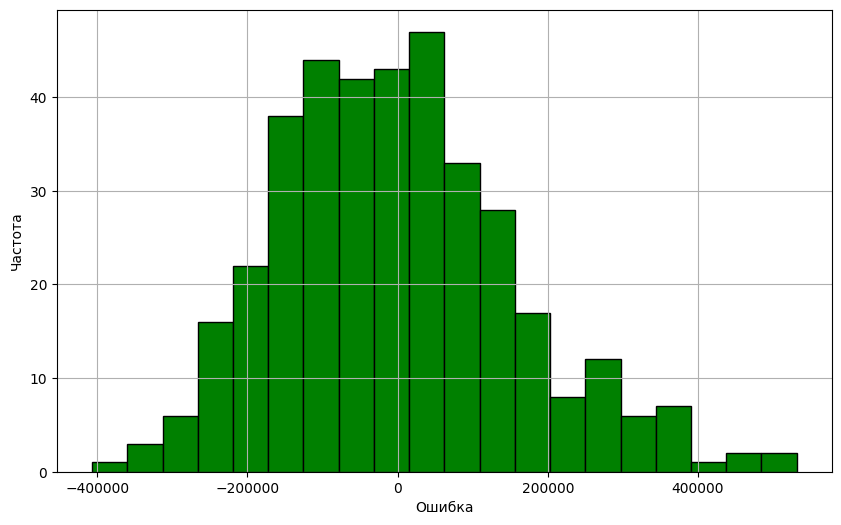

In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\yolff\OneDrive\Документы\Downloads\used_cars_dataset.csv")

def handle_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

df_clean = handle_outliers(df, 'Price')

categorical_cols = ['Brand_Model', 'Engine_Type', 'Condition', 'Region']
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), ['Year', 'Mileage'])
    ])

X = preprocessor.fit_transform(df_clean[categorical_cols + ['Year', 'Mileage']])
y = df_clean['Price'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = Ridge(alpha=1.0)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'MSE: {mse:.2f}')
print(f'R²: {r2:.2f}')

result = pd.DataFrame({
    'Фактическая цена': y_test[:6],
    'Предсказанная цена': y_pred[:6]
})
print(result)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.boxplot(df['Price'])
plt.title('До обработки')
plt.subplot(1, 2, 2)
plt.boxplot(df_clean['Price'])
plt.title('После обработки')
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(range(len(y_test)), y_test, label='Фактические цены', color='blue', alpha=0.7)
plt.scatter(range(len(y_pred)), y_pred, label='Предсказанные цены', color='red', alpha=0.7)
plt.xlabel('Автомобиль')
plt.ylabel('Цена')
plt.legend()
plt.grid(True)
plt.show()

errors = y_test - y_pred
plt.figure(figsize=(10, 6))
plt.hist(errors, bins=20, edgecolor='black', color='green')
plt.xlabel('Ошибка')
plt.ylabel('Частота')
plt.grid(True)
plt.show()